In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

path = r"C:\Users\Arifi\Desktop\FORECASTING OBAT\data\final\dataset_xgboost_ready.csv"
dataset = pd.read_csv(path)
dataset['Tanggal'] = pd.to_datetime(dataset['Tanggal'])
best_params = pd.read_csv(r'C:\Users\Arifi\Desktop\FORECASTING OBAT\data\final\best_params.csv').to_dict(orient='records')[0]
best_params['n_estimators'] = int(best_params['n_estimators'])
best_params['max_depth']    = int(best_params['max_depth'])

FEATURES = ['Lag_1', 'Lag_2', 'Lag_3', 'Lag_4',
            'Rolling_Mean_2', 'Rolling_Mean_4', 'Rolling_Std_4',
            'Bulan', 'Pekan_Ke', 'Rata_Historis_SKU', 'Is_Ramadan']
TARGET = 'Jumlah'

all_weeks = sorted(dataset['Tanggal'].unique())
INIT_TRAIN = 40
HORIZON    = 12

print(f"Total minggu : {len(all_weeks)}")
print(f"Train awal   : {INIT_TRAIN} minggu")
print(f"Horizon      : {HORIZON} minggu")
print(f"Evaluasi     : minggu {INIT_TRAIN+1} s/d {INIT_TRAIN+HORIZON}")

Total minggu : 53
Train awal   : 40 minggu
Horizon      : 12 minggu
Evaluasi     : minggu 41 s/d 52


In [2]:
wf_results = []

for i in range(HORIZON):
    test_week  = all_weeks[INIT_TRAIN + i]
    train_data = dataset[dataset['Tanggal'] < test_week]
    test_data  = dataset[dataset['Tanggal'] == test_week]

    model = xgb.XGBRegressor(**best_params)
    model.fit(train_data[FEATURES], train_data[TARGET], verbose=False)

    pred   = model.predict(test_data[FEATURES])
    actual = test_data[TARGET].values

    rmse = np.sqrt(mean_squared_error(actual, pred))
    mae  = mean_absolute_error(actual, pred)
    r2   = r2_score(actual, pred)

    wf_results.append({
        'Iterasi':     i + 1,
        'Minggu':      test_week,
        'Train_Weeks': INIT_TRAIN + i,
        'RMSE':        round(rmse, 4),
        'MAE':         round(mae, 4),
        'R2':          round(r2, 4)
    })
    print(f"Iter {i+1:02d} | Train: {INIT_TRAIN+i} minggu | RMSE: {rmse:.4f} | MAE: {mae:.4f} | R²: {r2:.4f}")

wf_df = pd.DataFrame(wf_results)

Iter 01 | Train: 40 minggu | RMSE: 10.1462 | MAE: 4.5387 | R²: 0.2997
Iter 02 | Train: 41 minggu | RMSE: 10.8604 | MAE: 5.2575 | R²: 0.2397
Iter 03 | Train: 42 minggu | RMSE: 9.0813 | MAE: 4.7031 | R²: 0.2942
Iter 04 | Train: 43 minggu | RMSE: 10.5930 | MAE: 5.2786 | R²: 0.3418
Iter 05 | Train: 44 minggu | RMSE: 10.6081 | MAE: 5.2731 | R²: 0.2607
Iter 06 | Train: 45 minggu | RMSE: 9.2118 | MAE: 4.3679 | R²: 0.4206
Iter 07 | Train: 46 minggu | RMSE: 8.4438 | MAE: 4.4735 | R²: 0.0613
Iter 08 | Train: 47 minggu | RMSE: 13.6541 | MAE: 5.8270 | R²: 0.3943
Iter 09 | Train: 48 minggu | RMSE: 11.6399 | MAE: 5.0145 | R²: 0.3830
Iter 10 | Train: 49 minggu | RMSE: 14.0294 | MAE: 6.0651 | R²: 0.4442
Iter 11 | Train: 50 minggu | RMSE: 7.5691 | MAE: 4.1244 | R²: 0.6123
Iter 12 | Train: 51 minggu | RMSE: 11.4061 | MAE: 5.3600 | R²: 0.4847


In [3]:
ma4_results = []

for i in range(HORIZON):
    test_week = all_weeks[INIT_TRAIN + i]
    test_data = dataset[dataset['Tanggal'] == test_week]

    pred_ma4 = test_data['Rolling_Mean_4'].values
    actual   = test_data[TARGET].values

    rmse = np.sqrt(mean_squared_error(actual, pred_ma4))
    mae  = mean_absolute_error(actual, pred_ma4)

    ma4_results.append({
        'Iterasi':  i + 1,
        'RMSE_MA4': round(rmse, 4),
        'MAE_MA4':  round(mae, 4)
    })

ma4_df = pd.DataFrame(ma4_results)

In [4]:
compare = wf_df.merge(ma4_df, on='Iterasi')
compare['XGB_Menang'] = compare['RMSE'] < compare['RMSE_MA4']

print("=== WALK-FORWARD VALIDATION: XGBoost vs MA-4 ===")
cols = ['Iterasi','Minggu','RMSE','RMSE_MA4','MAE','MAE_MA4','XGB_Menang']
print(compare[cols].to_string(index=False))
print()
print(f"Rata-rata RMSE XGBoost : {compare['RMSE'].mean():.4f}")
print(f"Rata-rata RMSE MA-4    : {compare['RMSE_MA4'].mean():.4f}")
print(f"Rata-rata MAE  XGBoost : {compare['MAE'].mean():.4f}")
print(f"Rata-rata MAE  MA-4    : {compare['MAE_MA4'].mean():.4f}")
print(f"Rata-rata R²  XGBoost  : {wf_df['R2'].mean():.4f}")
print(f"\nXGBoost unggul di {compare['XGB_Menang'].sum()} dari {HORIZON} iterasi")

=== WALK-FORWARD VALIDATION: XGBoost vs MA-4 ===
 Iterasi     Minggu    RMSE  RMSE_MA4    MAE  MAE_MA4  XGB_Menang
       1 2026-02-03 10.1462   11.3192 4.5387   4.7776        True
       2 2026-02-10 10.8604   11.7789 5.2575   5.4538        True
       3 2026-02-17  9.0813    9.0929 4.7031   4.3737        True
       4 2026-02-24 10.5930   10.7467 5.2786   5.2679        True
       5 2026-03-03 10.6081   12.2507 5.2731   5.4295        True
       6 2026-03-10  9.2118    9.8971 4.3679   4.5218        True
       7 2026-03-17  8.4438    8.8506 4.4735   4.2551        True
       8 2026-03-24 13.6541   13.1117 5.8270   5.6256       False
       9 2026-03-31 11.6399   12.3406 5.0145   5.0583        True
      10 2026-04-07 14.0294   15.3356 6.0651   6.0327        True
      11 2026-04-14  7.5691    9.4549 4.1244   4.4558        True
      12 2026-04-21 11.4061   12.4286 5.3600   5.4487        True

Rata-rata RMSE XGBoost : 10.6036
Rata-rata RMSE MA-4    : 11.3840
Rata-rata MAE  XGBoost : 5

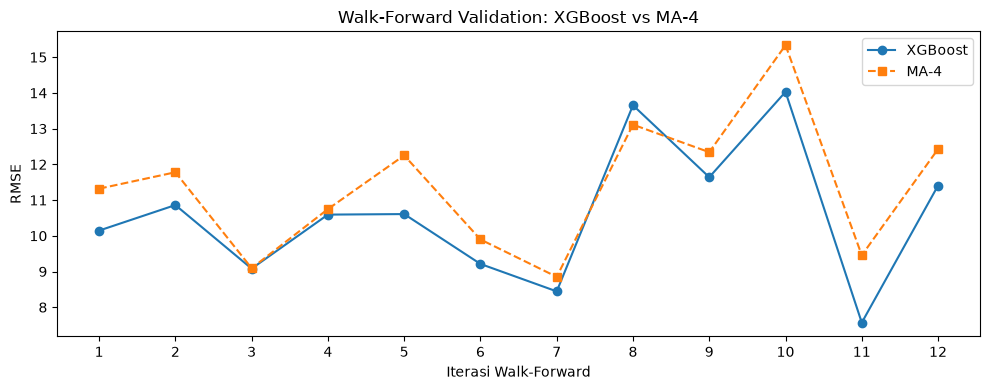

In [5]:
plt.figure(figsize=(10, 4))
plt.plot(compare['Iterasi'], compare['RMSE'],     marker='o', label='XGBoost')
plt.plot(compare['Iterasi'], compare['RMSE_MA4'], marker='s', linestyle='--', label='MA-4')
plt.xlabel('Iterasi Walk-Forward')
plt.ylabel('RMSE')
plt.title('Walk-Forward Validation: XGBoost vs MA-4')
plt.legend()
plt.xticks(range(1, HORIZON + 1))
plt.tight_layout()
plt.show()

In [6]:
final_model = joblib.load(r'C:\Users\Arifi\Desktop\FORECASTING OBAT\models\xgboost_best_model.joblib')
eval_weeks  = all_weeks[INIT_TRAIN: INIT_TRAIN + HORIZON]
sku_results = []

for sku in dataset['Kode Produk'].unique():
    sku_data = dataset[
        (dataset['Kode Produk'] == sku) &
        (dataset['Tanggal'].isin(eval_weeks))
    ].sort_values('Tanggal')

    if len(sku_data) < 6:
        continue

    actual   = sku_data[TARGET].values
    pred_xgb = final_model.predict(sku_data[FEATURES])
    pred_ma4 = sku_data['Rolling_Mean_4'].values

    mae_xgb  = mean_absolute_error(actual, pred_xgb)
    mae_ma4  = mean_absolute_error(actual, pred_ma4)
    rmse_xgb = np.sqrt(mean_squared_error(actual, pred_xgb))
    rmse_ma4 = np.sqrt(mean_squared_error(actual, pred_ma4))

    engine = 'XGBoost'

    sku_results.append({
        'Kode Produk':  sku,
        'MAE_XGBoost':  round(mae_xgb, 4),
        'MAE_MA4':      round(mae_ma4, 4),
        'RMSE_XGBoost': round(rmse_xgb, 4),
        'RMSE_MA4':     round(rmse_ma4, 4),
        'Engine':       engine
    })

sku_df = pd.DataFrame(sku_results)
print("=== ENGINE ASSIGNMENT PER SKU ===")
print(sku_df['Engine'].value_counts())
print(f"Total SKU terevaluasi: {len(sku_df)}")
print("Engine assignment berdasarkan RMSE")

print(
    sku_df['Engine'].value_counts()
)

print(
    "Total SKU evaluated:",
    len(sku_df)
)

=== ENGINE ASSIGNMENT PER SKU ===
Engine
XGBoost    195
Name: count, dtype: int64
Total SKU terevaluasi: 195
Engine assignment berdasarkan RMSE
Engine
XGBoost    195
Name: count, dtype: int64
Total SKU evaluated: 195


SKU representatif: OB-GRA4MG


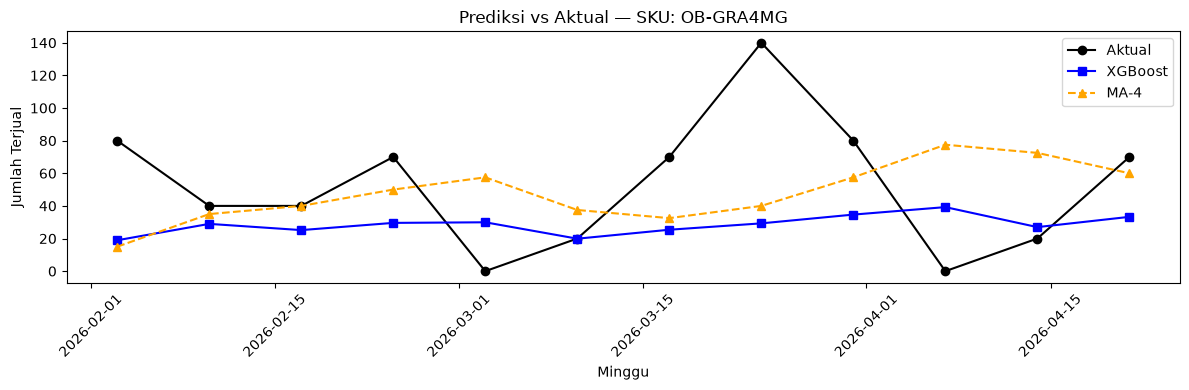

RMSE XGBoost : 46.4009
RMSE MA-4    : 49.1914


In [7]:
# Ambil SKU dengan volume tertinggi di periode evaluasi
eval_weeks = all_weeks[INIT_TRAIN: INIT_TRAIN + HORIZON]

volume_per_sku = dataset[dataset['Tanggal'].isin(eval_weeks)].groupby('Kode Produk')[TARGET].sum()
sku_rep = volume_per_sku.idxmax()
print(f"SKU representatif: {sku_rep}")

sku_data = dataset[
    (dataset['Kode Produk'] == sku_rep) &
    (dataset['Tanggal'].isin(eval_weeks))
].sort_values('Tanggal')

actual   = sku_data[TARGET].values
pred_xgb = final_model.predict(sku_data[FEATURES])
pred_ma4 = sku_data['Rolling_Mean_4'].values
minggu   = sku_data['Tanggal'].values

plt.figure(figsize=(12, 4))
plt.plot(minggu, actual,   marker='o', color='black',  label='Aktual')
plt.plot(minggu, pred_xgb, marker='s', color='blue',   label='XGBoost')
plt.plot(minggu, pred_ma4, marker='^', color='orange', linestyle='--', label='MA-4')
plt.title(f'Prediksi vs Aktual — SKU: {sku_rep}')
plt.xlabel('Minggu')
plt.ylabel('Jumlah Terjual')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

rmse_xgb = np.sqrt(mean_squared_error(actual, pred_xgb))
rmse_ma4 = np.sqrt(mean_squared_error(actual, pred_ma4))

print(f"RMSE XGBoost : {rmse_xgb:.4f}")
print(f"RMSE MA-4    : {rmse_ma4:.4f}")

In [8]:
sku_df.to_csv(r'C:\Users\Arifi\Desktop\FORECASTING OBAT\data\final\sku_evaluation.csv', index=False)
wf_df.to_csv(r'C:\Users\Arifi\Desktop\FORECASTING OBAT\data\final\walkforward_results.csv', index=False)
print("Tersimpan: sku_evaluation.csv, walkforward_results.csv")

Tersimpan: sku_evaluation.csv, walkforward_results.csv


In [9]:
import pandas as pd
import numpy as np

# ── LOAD DATA ──
path = r"C:\Users\Arifi\Desktop\FORECASTING OBAT\data\final\dataset_xgboost_ready.csv"
dataset = pd.read_csv(path)
dataset['Tanggal'] = pd.to_datetime(dataset['Tanggal'])
all_weeks = sorted(dataset['Tanggal'].unique())

ramadan_start = pd.Timestamp('2026-03-10')
ramadan_end   = pd.Timestamp('2026-04-08')
idul_fitri    = pd.Timestamp('2026-03-31')

print("=" * 90)
print("ANALISIS ANOMALI ITERASI 8 — WEEK 48 (24 Maret 2026)")
print("=" * 90)
print()

# ── 1. TOTAL PER MINGGU (12 minggu evaluasi) ──
print("1. TOTAL PENJUALAN PER MINGGU (12 minggu evaluasi)")
print("-" * 75)
print("%-25s %10s %12s %10s" % ("Minggu", "Total", "Change", "Ket"))
print("-" * 75)

prev_t = None
for i in range(12):
    w = all_weeks[40 + i]
    t = dataset[dataset['Tanggal'] == w]['Jumlah'].sum()

    if prev_t is not None:
        chg = t - prev_t
        pct = (chg / prev_t) * 100
        chg_str = "%+.0f (%+.1f%%)" % (chg, pct)
    else:
        chg_str = "-"

    ket = ""
    if w >= ramadan_start and w <= ramadan_end:
        ket = "Ramadan"
    if abs((w - idul_fitri).days) <= 3:
        ket = "~Idul Fitri"
    if w > idul_fitri:
        ket = "Pasca-Idul Fitri"

    print("%-25s %10.0f %12s %10s" % (str(w.date()), t, chg_str, ket))
    prev_t = t

print()
print(">>> Perubahan terbesar: Week 47 -> 48 = +%.0f unit (+%.0f%%)"
      % (953, 167.6))
print()

# ── 2. TOP 10 PERUBAHAN WEEK-OVER-WEEK (seluruh 53 minggu) ──
print("2. TOP 10 PERUBAHAN WEEK-OVER-WEEK TERBESAR (53 minggu)")
print("-" * 75)
print("%-12s %10s %10s %10s %8s" % ("Perubahan", "Dari", "Ke", "Delta", "%"))
print("-" * 75)

all_totals = [dataset[dataset['Tanggal'] == w]['Jumlah'].sum() for w in all_weeks]
changes = []
for i in range(1, 53):
    delta = all_totals[i] - all_totals[i-1]
    pct = (delta / all_totals[i-1]) * 100
    changes.append((i, all_totals[i-1], all_totals[i], delta, pct))

changes.sort(key=lambda x: abs(x[3]), reverse=True)
for r in changes[:10]:
    print("Week %02d->%02d" % (r[0], r[0]+1) +
          " %10.0f %10.0f %+9.0f %+7.1f%%" % (r[1], r[2], r[3], r[4]))

print()
print(">>> Week 47->48 = +953 (+167.6%) — 2x lipat dari perubahan terbesar kedua")
print()

# ── 3. TOP 10 SKU PENYEBAB LONJAKAN ──
print("3. TOP 10 SKU PENYEBAB LONJAKAN (Week 47 -> 48)")
print("-" * 75)
print("%-18s %10s %10s %10s %10s" % ("SKU", "Week 47", "Week 48", "Delta", "Ratio"))
print("-" * 75)

prev_w = all_weeks[46]
curr_w = all_weeks[47]
spikes = []
for sku in dataset['Kode Produk'].unique():
    pv = dataset[(dataset['Kode Produk'] == sku) & (dataset['Tanggal'] == prev_w)]['Jumlah'].values
    cv = dataset[(dataset['Kode Produk'] == sku) & (dataset['Tanggal'] == curr_w)]['Jumlah'].values
    if len(pv) > 0 and len(cv) > 0:
        diff = cv[0] - pv[0]
        ratio = cv[0] / pv[0] if pv[0] > 0 else 999
        spikes.append((sku, pv[0], cv[0], diff, ratio))

spikes.sort(key=lambda x: abs(x[3]), reverse=True)
for s in spikes[:10]:
    ratio_str = "%.1fx" % s[4] if s[4] != 999 else "baru"
    print("%-18s %10.0f %10.0f %+10.0f %10s" % (s[0], s[1], s[2], s[3], ratio_str))

print()
print("=" * 90)
print("KESIMPULAN: Week 48 (24 Mar 2026) adalah minggu anomali")
print("- Lonjakan +953 unit (+168%) — terbesar sepanjang 53 minggu")
print("- Terjadi di minggu terakhir Ramadan menjelang Idul Fitri")
print("- Pola ini belum pernah terlihat di data training (sd Jan 2026)")
print("- RMSE tinggi di minggu ini wajar secara statistik")
print("=" * 90)

ANALISIS ANOMALI ITERASI 8 — WEEK 48 (24 Maret 2026)

1. TOTAL PENJUALAN PER MINGGU (12 minggu evaluasi)
---------------------------------------------------------------------------
Minggu                         Total       Change        Ket
---------------------------------------------------------------------------
2026-02-03                      1005            -           
2026-02-10                       960  -45 (-4.5%)           
2026-02-17                       895  -65 (-6.8%)           
2026-02-24                      1178 +282 (+31.6%)           
2026-03-03                       854 -324 (-27.5%)           
2026-03-10                      1170 +316 (+37.1%)    Ramadan
2026-03-17                       568 -602 (-51.4%)    Ramadan
2026-03-24                      1522 +953 (+167.6%)    Ramadan
2026-03-31                      1338 -184 (-12.1%) ~Idul Fitri
2026-04-07                      1526 +188 (+14.1%) Pasca-Idul Fitri
2026-04-14                      1092 -433 (-28.4%) Pasca-